### Hybrid fixed-point/phase arithmetic

$
\newcommand{\ket}[1]{\left|#1\right\rangle}
\newcommand{\bra}[1]{\left\langle #1\right|}
\newcommand{\braket}[2]{\left\langle #1 \middle| #2 \right\rangle}
\newcommand{\ketbra}[2]{\left|#1\right\rangle\!\left\langle #2\right|}
$

In [2]:
# allows us to have visibility on our package without installing it in editing mode
import sys;
if ".." not in sys.path: sys.path.append("..")
import numpy as np

The hybrid fixed-point/phase arithmetic coin separates the discontinuous Metropolis-Hastings clipping from the smooth exponential. Instead of approximating the full kinked acceptance function directly by GQSP, the circuit first computes the energy difference in signed fixed-point arithmetic, replaces negative energy differences by zero, and then applies phase arithmetic only to the smooth exponential branch.

Let $W=F+1$ be the signed fixed-point width, and let $M=n+\binom{n}{2}$ be the number of Ising energy terms. The coefficients are normalized by $\alpha=2(\sum_i |h_i|+\sum_{i<j}|J_{ij}|)$, so the fixed-point register stores $\Delta E/\alpha$ in signed fixed point format with a single integer bit and $F$ fractional bits. The constant $\alpha$ is chosen such that the normalized energy difference between each pair of configuration is always in $[-1, 1]$, and also every partial sum of such energy terms. 

The fixed point arithmetics also check whether the value $x = \Delta E/\alpha$ resulting from the sums of energy terms is positive or negative:
* we first check the sign of $\Delta E$, which is determined by the single integer bit in the signed fixed point representation, for negative values we swap the fixed point register with the one holding the value $0$ (so that $\exp(-\beta \alpha 0) = 1$ meaning the move is always accepted);
* the phase arithmetic must be applied to approximate the target function, $g(x) = \exp(-\frac{\beta\alpha}{2} x)$ under the guarantee that $x \ge 0$. 

The circuit has four stages. 
1. The delta-energy block computes $\Delta E=E(y)-E(x)$ into a signed $W$-bit register.
2. The sign bit controls a swap between the delta register and an all-zero register, so negative values are replaced by zero. 
3. The square-root exponential arithmetic block applies the smooth map $z\mapsto \exp[-(\beta\alpha/2)z]$. 
4. The conditional swap and the delta-energy computation are uncomputed.



## Resources

Let $\ell_W := \log_2(W)$, $\ell_M := \log_2(M)$, 
$m:=\log_2(\frac{\beta\alpha}{2\log(\varepsilon_\text{tail}^{-1})})$, and 
$\ell\ell_t := \log_2(m)$. We assume tail truncation is active and $m\ge 3$. The following upper bounds hold:

| Component | Non-Clifford depth | Total qubits |
|---|---:|---:|
| Conditional terms loader | $0$ | $MW+2M-n$ |
| Three-to-two compressor | $3$ | $5$ |
| Wallace tree adder, with $r=2M$ inputs | $4\ell_M+6(W-1)$ | $6WM-2W-2M+1$ |
| Delta-energy block | $4\ell_M+6(W-1)$ | $2n+6WM-2W-2M+1$ |
| One-body PREPARE | $2\ell_W$ | $W$ |
| One-body SELECT | $0$ | $2W$ |
| Controlled one-body SELECT | $1$ | $3W$ |
| One-body reflection | $6\ell_W-3$ | $W+2$ |
| Controlled one-body reflection | $6\ell_W-3$ | $W+3$ |
| One-body qubitized operator | $10\ell_W-3$ | $2W+2$ |
| Controlled one-body qubitized operator | $10\ell_W-2$ | $3W+2$ |
| Square-root exponential arithmetic | $d(30\ell_W-1)+3$ | $3W+2$ |
| Positive-part selector | $3$ | $3W$ |
| Cutoff-tail block | $6\ell\ell_t-3+W$ | $2W+3$ |
| Hybrid phase arithmetic (with tail truncation) | $d(30\ell_W-1)+8\ell_M+14W-2m+12\ell\ell_t-9$ | $2n+6WM-2M+2$ |

Let $\varepsilon$ the allowed error budgeted half for the discretization error and half for the non-linear function. From the classical arithmetic notebook (FPGA implementation) we have determined $F = 3.5 \log_2(2n \varepsilon^{-1})$ in $W = 1 + F$. We also recall $M = n + \binom{n}{2}$. Finally, we later choose $d = 1 + \log_2(\varepsilon^{-1})$. 

Once fixed these values, we perform the following simplifications: $M \le n^2$, $\ell_{\varepsilon} := \log_2(1/\varepsilon)$, $\ell_n := \log_2(n)$. Let $S = \ell_n + \ell_\varepsilon + 1$ and $\ell_S := \log_2(1 + \frac{7}{2} S)$. We keep $m$ and $\ell\ell_t$ as defined above.

| Component | Non-Clifford depth | Total qubits |
|---|---:|---:|
| Conditional terms loader | $0$ | $n^2\left(3+\frac{7}{2}S\right)-n$ |
| Three-to-two compressor | $3$ | $5$ |
| Wallace tree adder, with $r=2M$ inputs | $8\ell_n+21S$ | $4n^2+\left(21n^2-7\right)S-1$ |
| Delta-energy block | $8\ell_n+21S$ | $2n+4n^2+\left(21n^2-7\right)S-1$ |
| One-body PREPARE | $2\ell_S$ | $1+\frac{7}{2}S$ |
| One-body SELECT | $0$ | $2+7S$ |
| Controlled one-body SELECT | $1$ | $3+\frac{21}{2}S$ |
| One-body reflection | $6\ell_S-3$ | $3+\frac{7}{2}S$ |
| Controlled one-body reflection | $6\ell_S-3$ | $4+\frac{7}{2}S$ |
| One-body qubitized operator | $10\ell_S-3$ | $4+7S$ |
| Controlled one-body qubitized operator | $10\ell_S-2$ | $5+\frac{21}{2}S$ |
| Square-root exponential arithmetic | $(\ell_\varepsilon+1)(30\ell_S-1)+3$ | $5+\frac{21}{2}S$ |
| Positive-part selector | $3$ | $3+\frac{21}{2}S$ |
| Cutoff-tail block | $6\ell\ell_t-2+\frac{7}{2}S$ | $5+7S$ |
| Hybrid phase arithmetic (with tail truncation) | $30\ell_S(\ell_\varepsilon+1) +16\ell_n+49S+12\ell\ell_t+5$ | $2n+4n^2+21n^2S+2$ |

## Implementation

#### Conditional terms loader

The conditional terms loader writes all normalized Ising coefficients into $M = n + \binom{n}{2}$ signed $W$-bit words. Here the spin encoding is $s_i=(-1)^{x_i}$, so every Ising term is always present: the spin bits only determine its sign. The one-body term $h_i s_i$ is loaded as $+h_i$ when $x_i=0$ and as $-h_i$ when $x_i=1$. Similarly, the two-body term $J_{ij}s_i s_j$ is loaded as $+J_{ij}$ when $x_i\oplus x_j=0$ and as $-J_{ij}$ when $x_i\oplus x_j=1$.

For each two-body term, the loader uses two temporary flags: one copy of $x_i$ and one copy of $x_j$. One of these two flags is temporarily overwritten with the parity $x_i\oplus x_j$, which selects whether the loaded coefficient is $+J_{ij}$ or $-J_{ij}$. After the coefficient word has been loaded, the same CNOT is applied again to restore the copied flag before the fanout copies are uncomputed.

The loader is Clifford-only. Fanout, parity computation, coefficient selection, and uncomputation are all implemented with $X$ and CNOT gates. Therefore the non-Clifford depth is $0$, and the total qubit count is $n+MW+2\binom{n}{2}$.

<img src="gates/hybrid-load.png" style="width: 750px">

#### Three-to-two compressor

The three-to-two compressor is the reversible bit primitive used inside the Wallace tree. It computes the sum bit $s=a\oplus b\oplus c$ and the carry bit $k=ab\oplus ac\oplus bc$ into two clean target qubits. The sum computation is Clifford. The carry computation uses three Toffoli gates sharing the same target, giving non-Clifford depth $3$. The compressor uses $5$ qubits.

<img src="gates/three-two-compressor.png" style="width: 350px">

#### Wallace tree adder

The Wallace tree adder adds $r$ signed $W$-bit words modulo $2^W$. In the hybrid construction, $r=2M$, because the circuit adds $M$ terms from $E(y)$ and $M$ terms from $-E(x)$.

The Wallace reduction groups three whole $W$-bit rows into two whole $W$-bit rows. The number of reduction layers is at most $\lceil\log_{3/2}(r/2)\rceil$. Each layer has non-Clifford depth $3$, and the clean compute-uncompute pattern doubles this contribution. The final ripple carry-propagate adder computes and uncomputes $W-1$ carries, contributing $6(W-1)$.

Thus the Wallace tree adder has non-Clifford depth at most $6\lceil\log_{3/2}(r/2)\rceil+6(W-1)$ and qubit count $rW+(2W-1)(r-1)$. For $r=2M$, and using $6\lceil\log_{3/2}(M)\rceil \le 4 \log_2(M)$, this becomes 
* non-Clifford depth at most $4 \log_2(M) + 6(W-1)$, note 
* qubit count $6WM-2W-2M+1$.

<img src="gates/wallace.png" style="width: 750px">

#### Delta-energy block

The delta-energy block computes the normalized fixed-point value $(E(y)-E(x))/\alpha$. It uses one conditional terms loader to write the $M$ signed terms of $E(y)$, and a second conditional terms loader with inverted coefficients to write the $M$ signed terms of $-E(x)$. The resulting $2M$ signed $W$-bit words are then summed by the Wallace tree adder into the delta register. Finally, the two loaders are uncomputed, leaving only the signed delta-energy value.

Since the corrected conditional terms loader is Clifford-only, the loaders and their inverses do not contribute to the non-Clifford depth. The only non-Clifford contribution comes from the Wallace tree adder. Therefore, using the simplified Wallace bound above, the delta-energy block has non-Clifford depth at most $4\log_2(M)+6(W-1)$.

The total qubit count is obtained from the two spin registers, the two loaded term arrays, and the Wallace output-plus-scratch register. The loader flags are reused inside the Wallace scratch space, and the Wallace scratch is large enough to contain them. Hence the total qubit count is $2n+2MW+(2W-1)(2M-1)$, equivalently $2n+6WM-2W-2M+1$.

#### One-body PREPARE

The one-body preparation block prepares the unary LCU selection state for the $W$-qubit signal Hamiltonian used by the square-root exponential arithmetic. Instead of using a sequential Givens ladder, the rotations are arranged as a balanced binary tree over the coefficient weights. The total number of Givens rotations is still $W-1$, but rotations at the same tree level act on disjoint pairs of qubits and can therefore be parallelized.

The preparation has $\lceil \log_2 W\rceil$ Givens layers. Since each Givens rotation contributes non-Clifford depth $2$, the preparation block has non-Clifford depth $2\lceil \log_2 W\rceil$ and uses $W$ qubits.

#### One-body SELECT and controlled-SELECT

The one-body selection block applies the selected signed Pauli $Z_i$ on the $W$-qubit signal register. It uses only Clifford gates, so its non-Clifford depth is $0$, and its qubit count is $2W$.

The controlled one-body selection block adds one external control. The single control is fanout to $W-1$ more controls to ensure parallelization of the operations. The controlled Pauli part is implemented by controlled-controlled-$Z$ gates, which can be executed all in parallel in a single non-Clifford layer. Its non-Clifford depth is $1$, and its qubit count is $3W$.

#### One-body reflection and controlled reflection

The zero reflection acts on the unary selection register using two clean ancillas. The central multi-controlled operation has $W-1$ controls. Using Qiskit's `synth_mcx_2_clean_kg24`, and counting both `ccx` and `rccx` as one non-Clifford primitive layer while ignoring Clifford gates, its non-Clifford depth is at most $\lfloor 6\log_2(W-1)-3\rfloor$. It uses $W+2$ qubits.

The controlled zero reflection has one extra control, so the central multi-controlled operation has $W$ controls. Its non-Clifford depth is at most $\lfloor 6\log_2(W)-3\rfloor$, and it uses $W+3$ qubits.

#### Square-root exponential arithmetic

The square-root exponential arithmetic block implements the smooth branch $x\mapsto \exp(-\beta\alpha x/2)$ for $x > 0$. Here $\alpha$ is the external normalization of the energy difference, so that the normalized input satisfies $x=\Delta E/\alpha\in[0,1]$, with $\alpha=2(\sum_i |h_i|+\sum_{i<j}|J_{ij}|)$.

We may want to approximate the function only on an interval smaller than $[0,1]$, since the tail of the exponential is already below the desired error. If the maximum allowed tail error is $\varepsilon_\text{tail}$, the ideal cutoff would satisfy
$\exp(-\beta\alpha x_\text{cut}/2)\le \varepsilon_\text{tail}$, i.e.
$x_\text{cut}\ge \frac{2}{\beta\alpha}\log(\varepsilon_\text{tail}^{-1})$.
In the implementation we choose a power-of-two cutoff $x_\text{cut}=2^{-m}$ satisfying this condition, so that the rescaling below the cutoff is just a bit shift.

When no tail is discarded, the effective scale is $\alpha_\text{eff}=\alpha$ and $\kappa_\text{eff}=\beta\alpha/2$. When the tail is discarded, the input is rescaled as $x\mapsto u=x/x_\text{cut}$ and the effective scale becomes $\alpha_\text{eff}=\alpha x_\text{cut}$. Therefore
$\kappa_\text{eff}=\beta\alpha_\text{eff}/2=(\beta\alpha/2)x_\text{cut}$, and the implemented function on the non-tail interval is still
$\exp(-\beta\alpha_\text{eff}u/2)=\exp(-\beta\alpha x/2)$.

We find numerically that the degree of the polynomial necessary to implement the function up to accuracy $\varepsilon$ is:
$$
d=\left\lceil \kappa_\text{eff}+\log(1/\varepsilon)+1\right\rceil.
$$

Without tail truncation, $\kappa_\text{eff}=\beta\alpha/2$, so the degree grows linearly with $\beta\alpha$. With tail truncation, $x_\text{cut}=2^{-m}$ is chosen so that the discarded tail is below $\varepsilon_\text{tail}$, and therefore $\kappa_\text{eff}$ is reduced to a quantity of order $\log(1/\varepsilon_\text{tail})$. This is why a fixed moderate degree, such as $d=12$, can be sufficient in the FPGA setting for errors around $10^{-4}$, provided the tail cutoff is active.

The shifted Laurent implementation uses $d$ applications of the one-body qubitized operator, $2d$ applications of the controlled one-body qubitized operator, and $2d+1$ GQSP phase blocks. 

Counting three non-Clifford phase layers per GQSP phase block, and using the simplified bounds $10\lceil\log_2 W\rceil-3$ for the one-body qubitized operator and $10\lceil\log_2 W\rceil-2$ for the controlled one-body qubitized operator, the total non-Clifford depth is 
$\le d(30\lceil\log_2 W\rceil-1)+3$. 

The qubit count is $3W+2$.

#### Cutoff tail

The cutoff-tail block implements the optional truncation of the exponentially small positive tail. After the positive-part selector, the delta register stores a nonnegative fixed-point value $x=\Delta E/\alpha$. If a tail cutoff is used, we choose it to be a power of two, $x_\text{cut}=2^{-m}$, so that the rescaling below the cutoff is only a bit shift.

The block acts on three registers: the original $W$-bit delta register, a fresh $W$-bit signal register, and one tail flag. If $m=0$, no nontrivial cutoff is applied and the block only copies the delta register into the signal register using CNOT gates. If $m>0$, the block checks the first $m$ fractional bits of the delta register. If at least one of these bits is nonzero, then $x\ge 2^{-m}$ and the tail flag is set. If all these bits are zero, then $x<2^{-m}$ and the block writes the shifted value $2^m x$ into the signal register.

The shift $x\mapsto 2^m x$ is not a fixed-point multiplication. It is implemented by copying lower fractional bits of the delta register into shifted positions of the signal register using CNOT gates. Therefore the shift contributes no non-Clifford depth. The only non-Clifford contribution comes from the $m$-controlled threshold test used to compute the tail flag. This multi-controlled gate is synthesized with Qiskit's `synth_mcx_2_clean_kg24`.

Thus, for $m=0$ and $m=1$, the cutoff-tail block is Clifford-only and has non-Clifford depth $0$. For $m=2$, the threshold test is one Toffoli and has non-Clifford depth $1$. For $m\ge 3$, using the same convention as before, where both `ccx` and `rccx` count as one non-Clifford primitive layer, the non-Clifford depth is at most $6\log_2(m)-3$.

The block uses $2W+1$ qubits for $m\le 2$: the delta register, the signal register, and the tail flag. For $m\ge 3$, the KG24 synthesis of the internal $\mathrm{MCX}$ uses two additional clean ancillas, so the block uses $2W+3$ qubits.

#### Positive-part selector

The positive-part selector replaces negative fixed-point deltas by zero. It copies the sign bit of the delta register into a sign-control register, fans it out to $W$ controls using Clifford gates, and applies $W$ controlled swaps between the delta register and an all-zero register. The controlled swaps act on disjoint pairs of target qubits and can therefore be executed in parallel. 

Counting each controlled swap as 3 Toffoli non-Clifford layer, the selector has non-Clifford depth $3$. Since the selector is applied once before and once after the square-root exponential arithmetic block, its total contribution to the non-Clifford depth is $6$. It uses $3W$ qubits: the delta register, the zero register, and the sign-control flags.

#### Hybrid phase arithmetic

The full hybrid phase arithmetic block computes $\Delta E=E(y)-E(x)$, clips negative values to zero, applies the square-root exponential arithmetic block, restores the signed delta register, and uncomputes the delta-energy calculation.

## Error of the polynomial approximation

This plot shows the polynomial approximation implemented by the square-root exponential arithmetic block for the clipped smooth branch $x\mapsto \exp(-\beta\alpha x/2)$. The power-of-two tail cutoff is useful only when $\beta\alpha$ is large enough that the exponential has already become negligible before the end of the interval $x\in[0,1]$. 

In the example below, $\beta=10$, $\alpha=100$, and therefore $\beta\alpha/2=500$. With $\varepsilon_\text{tail}=\varepsilon/2=5\cdot 10^{-3}$, the exponential is already very small well before $x=1$, so the cutoff becomes active. Since the cutoff is chosen as a power of two, the rescaling below the cutoff is implemented by a bit shift rather than by a general fixed-point multiplication.

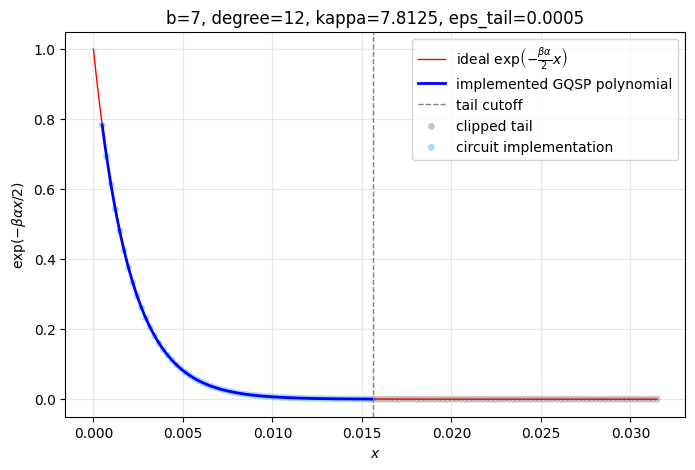

In [3]:
from monaqa2.qiskit.arithmetic_hybrid import plot_hybrid_phase_arithmetic, plot_error_hybrid_phase_arithmetic

F, beta, alpha, eps = 6, 10.0, 100.0, 1e-3
gate = plot_hybrid_phase_arithmetic(b=F + 1, beta=beta, alpha=alpha, eps=eps / 2, eps_tail=eps / 2, degree=12, is_mocked_angles=False)

The following plot shows how the error changes as a function of $\beta\alpha/2$. We recall the degree one choses to ensure a bounded error is $d=\left\lceil \kappa_\text{eff}+\log(1/\varepsilon)+1\right\rceil$. This depends on the factor $\kappa_\text{eff}$ such that:
* if there is no discarding of the tail, $\kappa_\text{eff} = \frac{\beta \alpha}{2}$;
* if we discard the tail, we choose a power-of-two cutoff $x_\text{cut}=2^{-m}$, where $m$ is the largest integer such that
$$\exp[-(\beta\alpha/2)2^{-m}]\le \varepsilon_\text{tail} \quad \Rightarrow \quad m=\left\lfloor \log_2\left(\frac{\beta\alpha/2}{\log(1/\varepsilon_\text{tail})}\right)\right\rfloor$$
In this case $\kappa_\text{eff} = \frac{\beta\alpha}{2}2^{-m} \le 2 \log_2(\varepsilon_\text{tail}^{-1})$.

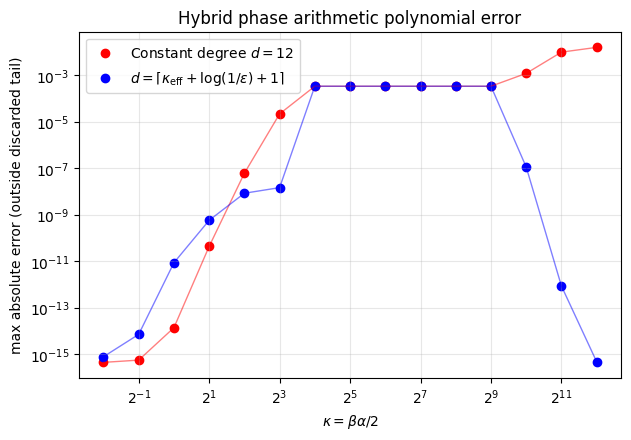

In [4]:
_ = plot_error_hybrid_phase_arithmetic(b=F + 1, eps=eps / 2, eps_tail=eps / 2, fixed_degree=12, is_mocked_angles=True)